A GAN model that generate 8x8 images of digit 0

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

In [12]:
# 1. Load Data (digit 0 only)
digits = load_digits()
X = digits.images[digits.target == 0] # filter out 0

# Normalize to [-1, 1]
X = (X / 16.0) * 2 - 1
X = X.reshape(-1, 64)


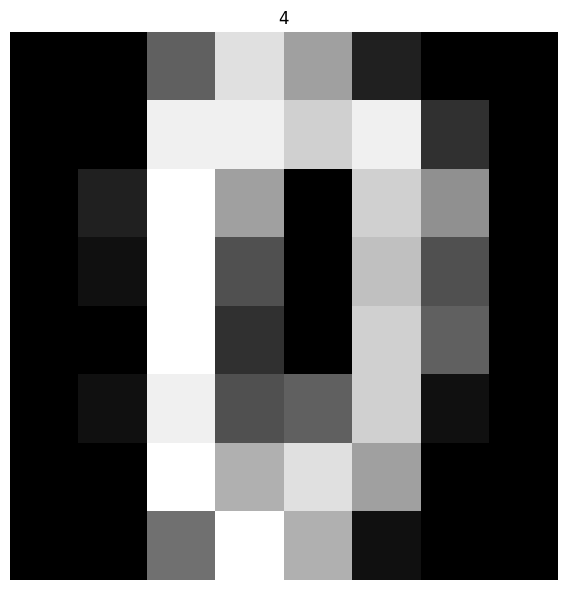

In [39]:
# 1) Lets plot 1 image
idx = 0
plt.figure(figsize=(6, 6))
plt.imshow(X[idx].reshape(8, 8), cmap='gray')

plt.title("0")
plt.axis('off')
plt.tight_layout()
plt.show()


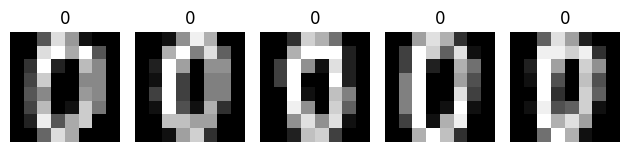

In [40]:
# 2) Lets plot 5 images

for i in range(5):
    plt.subplot(1, 5, i+1)   # 1 rows, 5 columns
    plt.imshow(X[i].reshape(8, 8), cmap='gray')
    plt.title("0")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [31]:
# 2. Build the 2 models

def build_generator():
    return tf.keras.Sequential([
        layers.Dense(64, activation='relu', input_dim=16),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='tanh')
    ])

def build_discriminator():
    return tf.keras.Sequential([
        layers.Dense(128, activation='relu', input_dim=64),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),  # IMPORTANT
        layers.Dense(1, activation='sigmoid')
    ])

generator = build_generator()
discriminator = build_discriminator()


# Optimizers (LOW LR = stability)
d_optimizer = tf.keras.optimizers.Adam(0.0005)
g_optimizer = tf.keras.optimizers.Adam(0.0001)

discriminator.compile(optimizer=d_optimizer, loss='binary_crossentropy')

# GAN model
discriminator.trainable = False
z = tf.keras.Input(shape=(16,))
img = generator(z)
valid = discriminator(img)

gan = tf.keras.Model(z, valid)
gan.compile(optimizer=g_optimizer, loss='binary_crossentropy')



[[ 1.1590875   1.1023857   0.81309613 -0.16189757 -1.36258514  0.45458225
  -0.12966492  1.24674012 -2.24821669 -0.47741406 -1.42578718  0.39058027
  -0.65723728  0.17222186 -2.53784518 -0.55338262]
 [-1.88614047  0.97182846 -1.91668481 -0.57596931 -3.32060706 -0.08384801
   0.25338935  0.94460991 -1.31443319  0.01475772 -0.0616308   1.08803568
   0.82472346 -0.25067005  2.28480607  1.35134299]
 [-0.02029659  0.23019122  1.22362998 -0.47117364 -0.29808514 -0.79612522
   1.09817202  1.00627742 -0.27104105  1.24744891 -0.0491099  -0.80181387
  -0.88038786 -1.40980766  1.38943679  1.48266933]
 [-0.00977013  1.84819521 -0.61408022  0.81086245  0.0822296  -0.65512801
  -2.31487657  0.89573317 -1.40474232  0.45548129  0.52386795 -0.10038393
   1.33109973  2.00318396 -1.440129    1.12609389]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


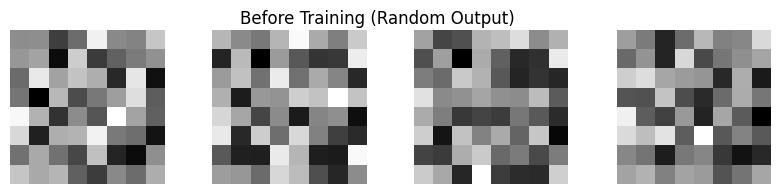

In [32]:
# BEFORE TRAINING (random generator output)
# Lets look what generator produces before training

import matplotlib.pyplot as plt

NUM_IMAGES = 4
noise = np.random.normal(0, 1, (NUM_IMAGES, 16))
print(noise)

generated_imgs = generator.predict(noise)


plt.figure(figsize=(10,2))
for i in range(NUM_IMAGES):
    plt.subplot(1,NUM_IMAGES,i+1)
    plt.imshow(generated_imgs[i].reshape(8,8), cmap='gray')
    plt.axis('off')

plt.suptitle("Before Training (Random Output)")
plt.show()

# Observ: Number do not seem like zero

In [14]:
# 3. Training: Took 20 minutes on Colab GPU

epochs = 3000
batch_size = 32

for epoch in range(epochs):

    # ---------------------
    # Train Discriminator
    # ---------------------
    discriminator.trainable = True

    for _ in range(5):

        idx = np.random.randint(0, X.shape[0], batch_size)
        real_imgs = X[idx]

        noise = np.random.normal(0, 1, (batch_size, 16))
        fake_imgs = generator.predict(noise, verbose=0)

        real_imgs += 0.05 * np.random.normal(size=real_imgs.shape)
        fake_imgs += 0.05 * np.random.normal(size=fake_imgs.shape)

        real_labels = np.ones((batch_size,1)) * 0.9
        fake_labels = np.zeros((batch_size,1)) + 0.1

        X_combined = np.vstack([real_imgs, fake_imgs])
        y_combined = np.vstack([real_labels, fake_labels])

        d_loss = discriminator.train_on_batch(X_combined, y_combined)

    # ---------------------
    # Train Generator
    # ---------------------
    discriminator.trainable = False

    noise = np.random.normal(0, 1, (batch_size, 16))
    misleading_labels = np.ones((batch_size,1))

    g_loss = gan.train_on_batch(noise, misleading_labels)

    # Logging
    if epoch % 200 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss:.4f} | G Loss: {g_loss:.4f}")



Epoch 0 | D Loss: 0.5869 | G Loss: 0.7978
Epoch 200 | D Loss: 0.3321 | G Loss: 2.2590
Epoch 400 | D Loss: 0.3312 | G Loss: 2.2747
Epoch 600 | D Loss: 0.3327 | G Loss: 2.2787
Epoch 800 | D Loss: 0.3371 | G Loss: 2.2686
Epoch 1000 | D Loss: 0.3436 | G Loss: 2.2502
Epoch 1200 | D Loss: 0.3498 | G Loss: 2.2241
Epoch 1400 | D Loss: 0.3559 | G Loss: 2.1956
Epoch 1600 | D Loss: 0.3603 | G Loss: 2.1765
Epoch 1800 | D Loss: 0.3625 | G Loss: 2.1724
Epoch 2000 | D Loss: 0.3634 | G Loss: 2.1739
Epoch 2200 | D Loss: 0.3639 | G Loss: 2.1739
Epoch 2400 | D Loss: 0.3639 | G Loss: 2.1778
Epoch 2600 | D Loss: 0.3636 | G Loss: 2.1808
Epoch 2800 | D Loss: 0.3631 | G Loss: 2.1843


In [17]:
# 4) Save the model
generator.save("generator_model.keras")


In [33]:
from tensorflow.keras.models import load_model

generator = load_model("generator_model.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step


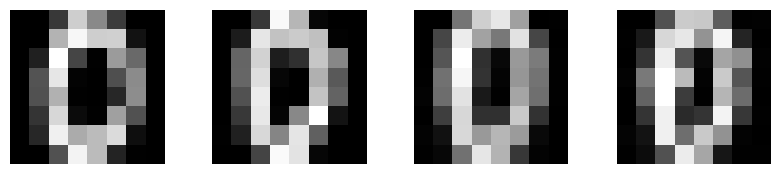

In [34]:
# 5) Use generator to create images of 0
NUM_IMAGES = 4
noise = np.random.normal(0, 1, (NUM_IMAGES, 16))
generated_imgs = generator.predict(noise)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,2))
for i in range(NUM_IMAGES):
    plt.subplot(1,NUM_IMAGES,i+1)
    plt.imshow(generated_imgs[i].reshape(8,8), cmap='gray')
    plt.axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step


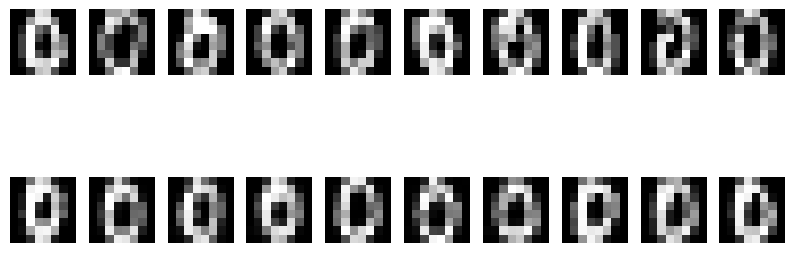

In [35]:

# 6. Compare actual images with generated images

noise = np.random.normal(0, 1, (10, 16))
generated_imgs = generator.predict(noise)

idx = np.random.randint(0, X.shape[0], 10)
real_imgs = X[idx]

plt.figure(figsize=(10,4))

# Real
for i in range(10):
    plt.subplot(2,10,i+1)
    plt.imshow(real_imgs[i].reshape(8,8), cmap='gray')
    plt.axis('off')

# Fake
for i in range(10):
    plt.subplot(2,10,i+11)
    plt.imshow(generated_imgs[i].reshape(8,8), cmap='gray')
    plt.axis('off')

plt.show()
